Link do colab:
https://colab.research.google.com/drive/1gX4pX7Id5FM21B-tZdgMSePbM3EXL2D7?usp=sharing

# Wczytanie danych


## Odczyt pliku

Wczytanie danych z pliku "/rna_results.txt"


In [ ]:
with open("/rna_results.txt", "r") as f:
  lines = f.readlines()

header_line = lines[4] # Get the 5th line as the header
data_lines = lines[5:] # Get the lines from the 6th line onwards

## Przetworzenie danych

Podzielenie wczytanych danych na wiersze i kolumny, tworząc strukturę danych przypominającą macierz. Pominięcie pustych linii.


In [ ]:
processed_data = []
for line in data_lines:
  cleaned_line = line.strip()
  # Skip empty lines, Check if the line is empty
  if not cleaned_line:
      continue
  # Split the line by spaces, assuming consistent spacing or delimiters between columns
  columns = cleaned_line.split()
  processed_data.append(columns)

# Process the header line
header = header_line.strip().split()
# Combine 'Group' and 'name' into 'Group name'
header[3:5] = ['Group name']


print("Header:", header)
print("First 5 data rows:", processed_data[:5])

Header: ['#', 'Model', 'Group#', 'Group name', 'RMSD', 'LDDT', 'TM_score', 'GDT_TS', 'Clash', 'CC_mask', 'CC_peaks', 'TEMPY_MI', 'TEMPY_SMOC', 'AI', 'AI_bb', 'AI_base']
First 5 data rows: [['1', 'R1107TS232_1', '232', 'AIchemy_RNA2', '4.52', '0.724', '0.564', '63.41', '14.93', '-', '-', '-', '-', '-', '-', '-'], ['2', 'R1107TS232_2', '232', 'AIchemy_RNA2', '4.85', '0.721', '0.498', '58.69', '9.05', '-', '-', '-', '-', '-', '-', '-'], ['3', 'R1107TS232_4', '232', 'AIchemy_RNA2', '5.31', '0.710', '0.488', '56.88', '11.76', '-', '-', '-', '-', '-', '-', '-'], ['4', 'R1107TS232_3', '232', 'AIchemy_RNA2', '5.94', '0.728', '0.487', '54.34', '17.19', '-', '-', '-', '-', '-', '-', '-'], ['5', 'R1107TS232_5', '232', 'AIchemy_RNA2', '5.02', '0.721', '0.473', '59.06', '10.40', '-', '-', '-', '-', '-', '-', '-']]


## Zapis do macierzy

Zapisanie przetworzonych danych do macierzy, używając biblioteki pandas.


In [ ]:
import pandas as pd

df_rna = pd.DataFrame(processed_data, columns=header)
display(df_rna.head())

,#,Model,Group#,Group name,RMSD,LDDT,TM_score,GDT_TS,Clash,CC_mask,CC_peaks,TEMPY_MI,TEMPY_SMOC,AI,AI_bb,AI_base
0,1,R1107TS232_1,232,AIchemy_RNA2,4.52,0.724,0.564,63.41,14.93,-,-,-,-,-,-,-
1,2,R1107TS232_2,232,AIchemy_RNA2,4.85,0.721,0.498,58.69,9.05,-,-,-,-,-,-,-
2,3,R1107TS232_4,232,AIchemy_RNA2,5.31,0.710,0.488,56.88,11.76,-,-,-,-,-,-,-
3,4,R1107TS232_3,232,AIchemy_RNA2,5.94,0.728,0.487,54.34,17.19,-,-,-,-,-,-,-
4,5,R1107TS232_5,232,AIchemy_RNA2,5.02,0.721,0.473,59.06,10.40,-,-,-,-,-,-,-


## Wyświetlenie macierzy

Wyświetlenie fragmentów utworzonej macierzy (head) oraz wymiarów (shape), aby zobaczyć jej strukturę.


In [ ]:
display(df_rna.head())
display(df_rna.shape)

,#,Model,Group#,Group name,RMSD,LDDT,TM_score,GDT_TS,Clash,CC_mask,CC_peaks,TEMPY_MI,TEMPY_SMOC,AI,AI_bb,AI_base
0,1,R1107TS232_1,232,AIchemy_RNA2,4.52,0.724,0.564,63.41,14.93,-,-,-,-,-,-,-
1,2,R1107TS232_2,232,AIchemy_RNA2,4.85,0.721,0.498,58.69,9.05,-,-,-,-,-,-,-
2,3,R1107TS232_4,232,AIchemy_RNA2,5.31,0.710,0.488,56.88,11.76,-,-,-,-,-,-,-
3,4,R1107TS232_3,232,AIchemy_RNA2,5.94,0.728,0.487,54.34,17.19,-,-,-,-,-,-,-
4,5,R1107TS232_5,232,AIchemy_RNA2,5.02,0.721,0.473,59.06,10.40,-,-,-,-,-,-,-


(131, 16)

# Ocena 3.0

Analiza statystyczna i wizualna kluczowych metryk strukturalnych:

Kluczowe metryki:
* RMSD,
* LDDT,
* TM_score,
* GDT_TS, Clash

Wykonano poniższe statystyki:
* Wartość minimalna
* Pierwszy kwartyl (25. percentyl)
* Mediana (50. percentyl)
* Trzeci kwartyl (75. percentyl)
* Wartość maksymalna
* Średnia arytmetyczna
* Odchylenie standardowe
* Rozstęp (różnica między wartością maksymalną a minimalną)
* Rozstęp międzykwartylowy (różnica między trzecim a pierwszym kwartylem)

## Przygotowanie danych

Wybranie kolumn odpowiadających metrykom strukturalnym (RMSD, LDDT, TM_score, GDT_TS, Clash) i upewnienie się, że dane są w odpowiednim formacie numerycznym.


**Uwagi**:
Wybierane są kolumny odpowiadające metrykom strukturalnym i konwertowane na typ numeryczny, wartości nienumeryczne są obsługiwane poprzez przekonwertowanie ich na NaN.


In [ ]:
metrics_columns = ['RMSD', 'LDDT', 'TM_score', 'GDT_TS', 'Clash']

# Select the columns using their names
df_metrics = df_rna[metrics_columns].copy()

# Convert columns to numeric, coercing errors to NaN
for col in metrics_columns:
  df_metrics[col] = pd.to_numeric(df_metrics[col], errors='coerce')

display(df_metrics.head())
display(df_metrics.info())

,RMSD,LDDT,TM_score,GDT_TS,Clash
0,4.52,0.724,0.564,63.41,14.93
1,4.85,0.721,0.498,58.69,9.05
2,5.31,0.710,0.488,56.88,11.76
3,5.94,0.728,0.487,54.34,17.19
4,5.02,0.721,0.473,59.06,10.40


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 131 entries, 0 to 130
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   RMSD      131 non-null    float64
 1   LDDT      131 non-null    float64
 2   TM_score  131 non-null    float64
 3   GDT_TS    131 non-null    float64
 4   Clash     131 non-null    float64
dtypes: float64(5)
memory usage: 5.2 KB


None

## Analiza statystyczna

Obliczanie wymaganych statystyk:
* Wartość minimalna - `min`,
* Pierwszy kwartyl - `25%`,
* mediana - `50%`,
* Trzeci kwartyl - `75%`,
* Wartość maksymalna `max`,
* Średnia arytmetyczna - `mean`,
* Odchylenie Standardowe - `std`,
* Rozstęp - `rnage`,
* rozstęp międzykwartylowy - `IQR`

dla wybranych metryk i wyświetlenie ich w tabeli.


In [ ]:
# Calculate descriptive statistics
descriptive_stats = df_metrics.describe()

# Calculate range
data_range = df_metrics.max() - df_metrics.min()
descriptive_stats.loc['range'] = data_range

# Calculate IQR (Q3 - Q1)
iqr = df_metrics.quantile(0.75) - df_metrics.quantile(0.25)
descriptive_stats.loc['iqr'] = iqr

# Display the complete table of descriptive statistics
display(descriptive_stats)

,RMSD,LDDT,TM_score,GDT_TS,Clash
count,131.000000,131.000000,131.000000,131.000000,131.000000
mean,19.880687,0.435221,0.284901,31.372672,24.816183
std,12.564820,0.125473,0.086125,11.642187,38.219974
min,4.520000,0.211000,0.135000,11.230000,0.000000
25%,11.635000,0.324500,0.232000,23.550000,2.035000
50%,18.980000,0.407000,0.264000,30.800000,6.780000
75%,23.540000,0.535500,0.336500,41.305000,28.700000
max,67.980000,0.728000,0.564000,63.410000,169.220000
range,63.460000,0.517000,0.429000,52.180000,169.220000
iqr,11.905000,0.211000,0.104500,17.755000,26.665000


## Wizualizacja rozkładów

Utworzenie histogramów i wykresów pudełkowych dla każdej z wybranych metryk.


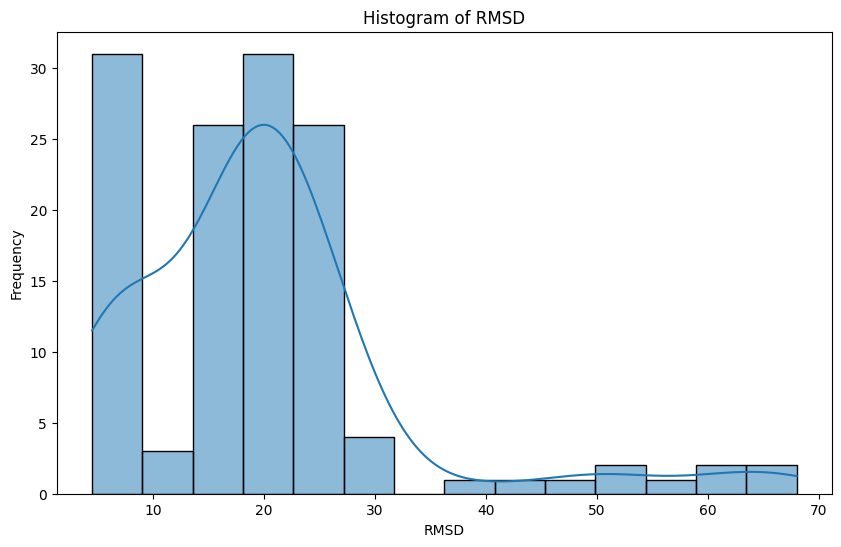

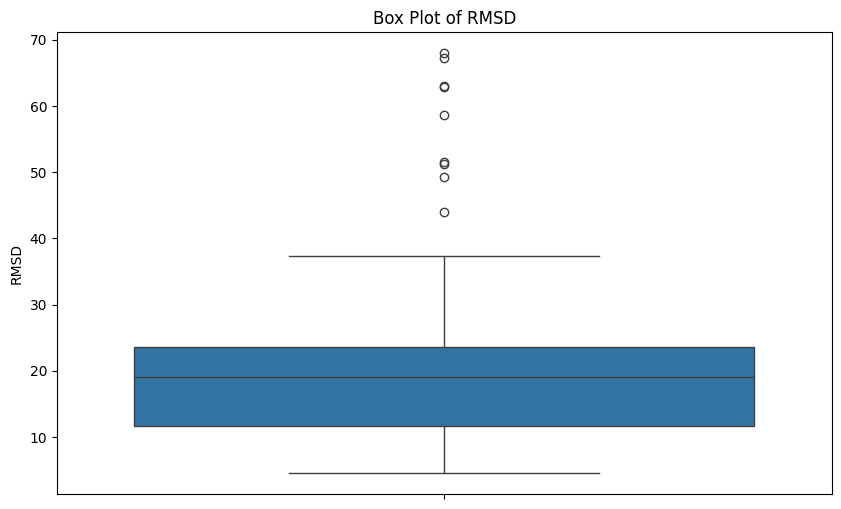

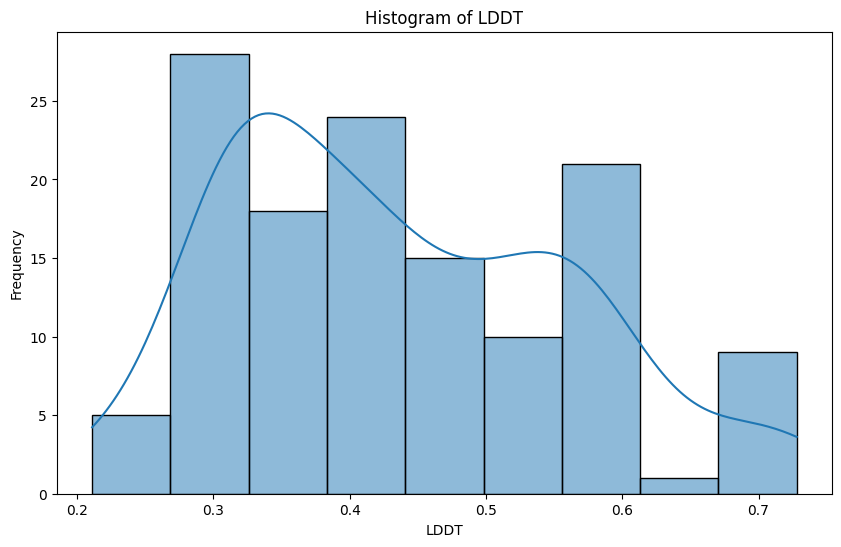

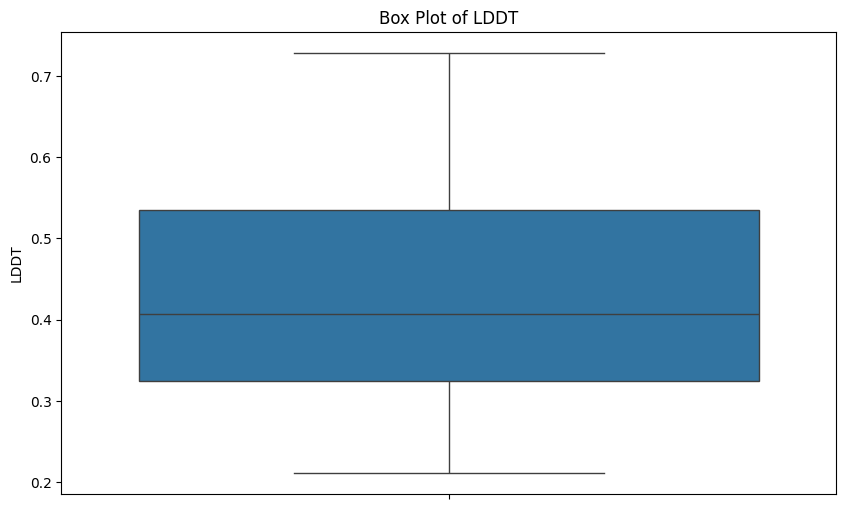

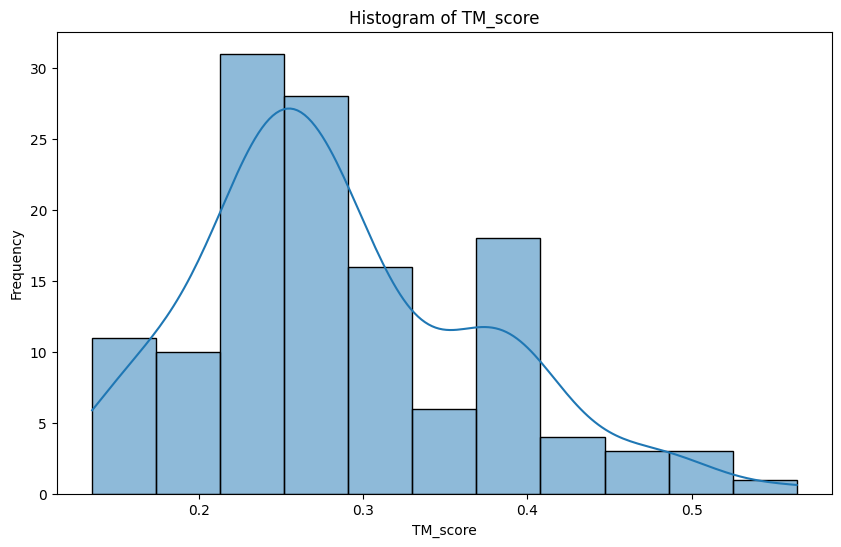

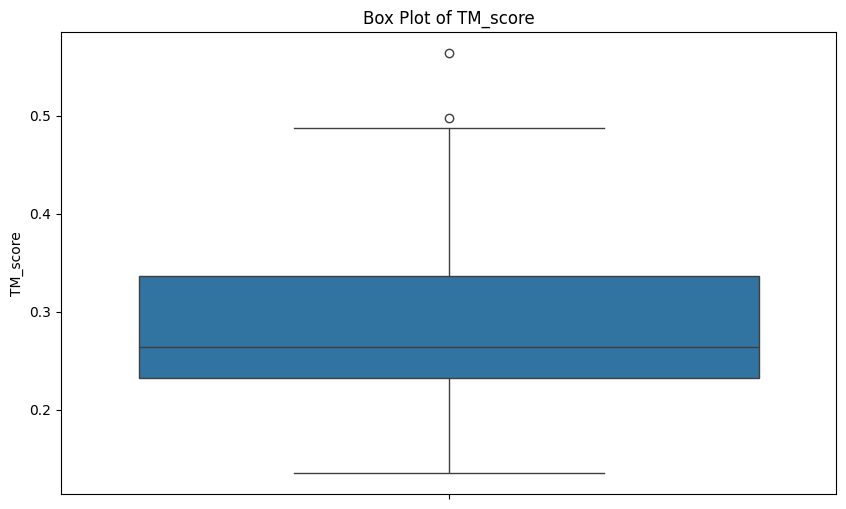

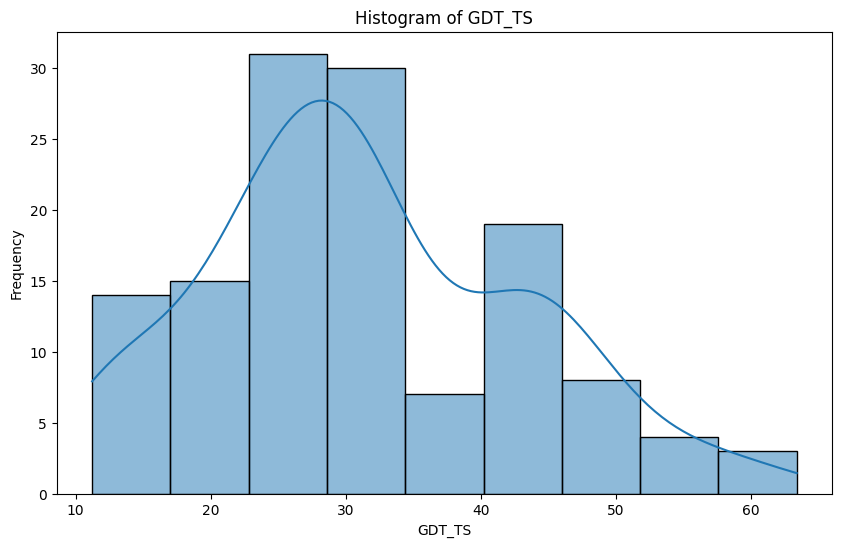

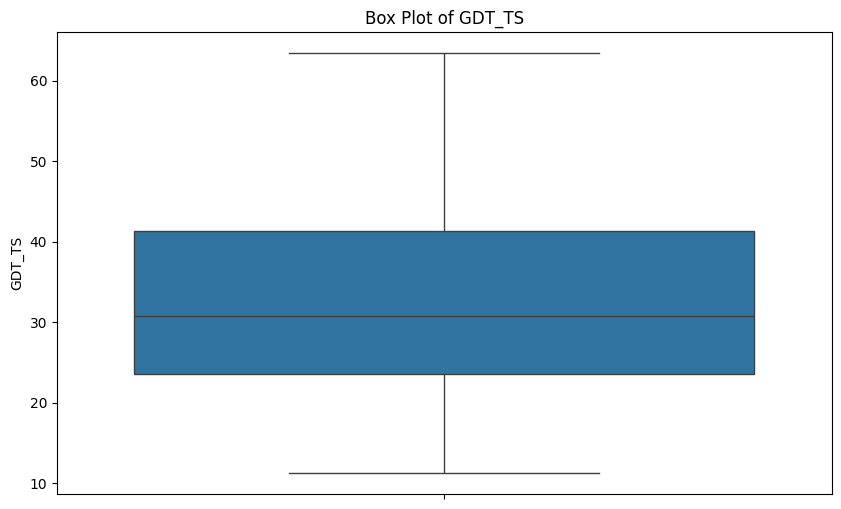

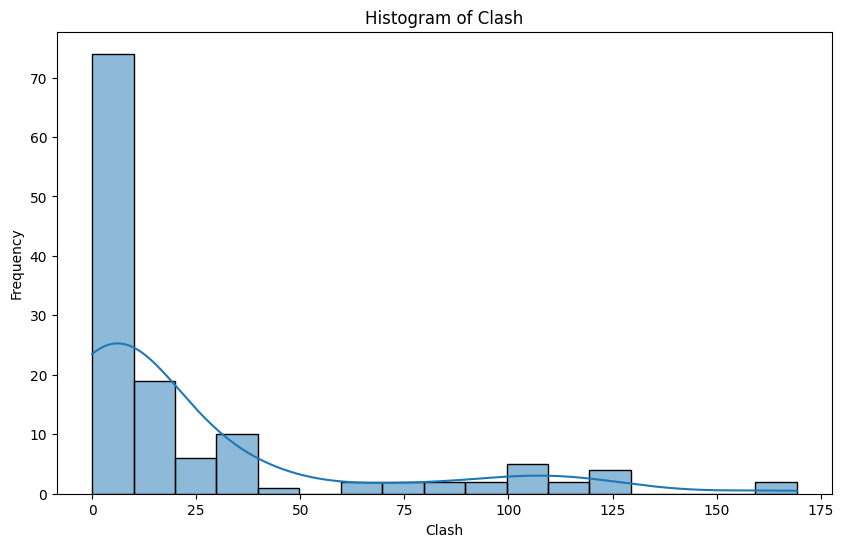

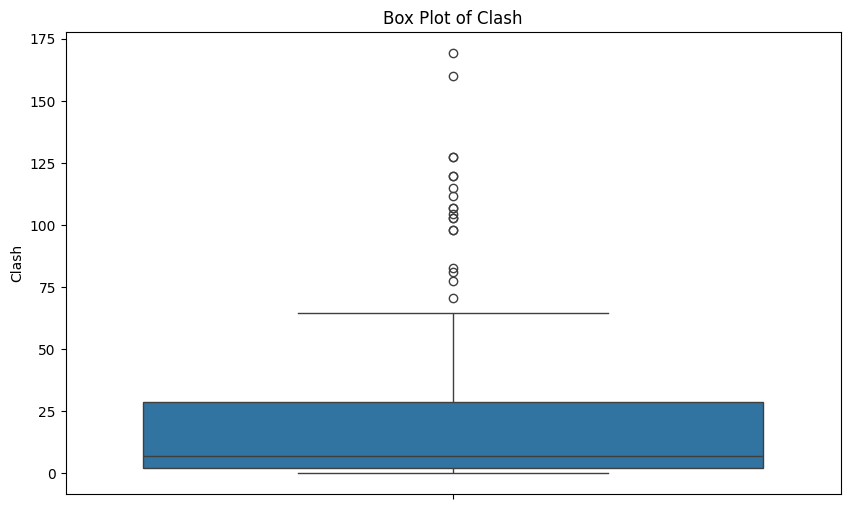

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in df_metrics.columns:
  plt.figure(figsize=(10, 6))
  sns.histplot(data=df_metrics, x=col, kde=True)
  plt.title(f'Histogram of {col}')
  plt.xlabel(col)
  plt.ylabel('Frequency')
  plt.show()

  plt.figure(figsize=(10, 6))
  sns.boxplot(data=df_metrics, y=col)
  plt.title(f'Box Plot of {col}')
  plt.ylabel(col)
  plt.show()

# Ocena 3.5
Analiza zależności między metrykami dla każdego modelu

## Wizualizacja zależności (Wykresy punktowe)

Utworzenie wykresów punktowych dla każdej pary metryk strukturalnych, aby wizualnie ocenić zależności.

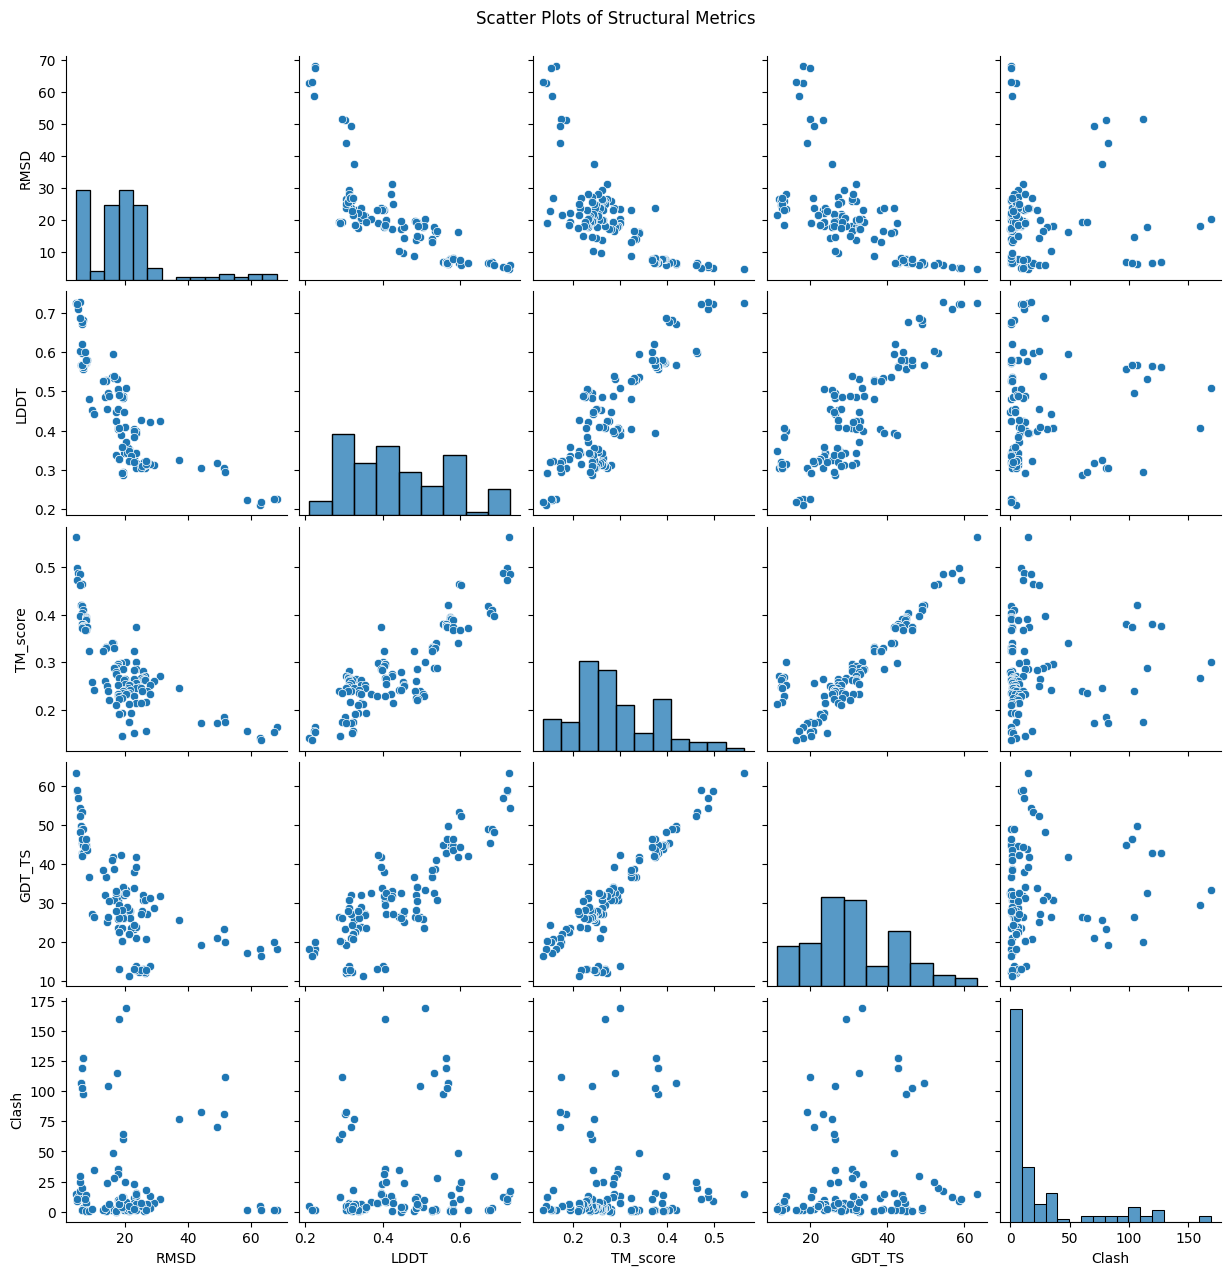

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df_metrics)
plt.suptitle('Scatter Plots of Structural Metrics', y=1.02)
plt.show()

## Korelacja Spearmana:


In [ ]:
from scipy.stats import spearmanr

# Calculate Spearman correlation matrix and p-values
correlation_matrix, p_value_matrix = spearmanr(df_metrics)

# Convert to DataFrames for better readability
correlation_df = pd.DataFrame(correlation_matrix, index=df_metrics.columns, columns=df_metrics.columns)
p_value_df = pd.DataFrame(p_value_matrix, index=df_metrics.columns, columns=df_metrics.columns)

print("Spearman Correlation Matrix:")
display(correlation_df)

print("\nP-value Matrix:")
display(p_value_df)

Spearman Correlation Matrix:


,RMSD,LDDT,TM_score,GDT_TS,Clash
RMSD,1.000000,-0.878655,-0.734306,-0.772916,-0.169054
LDDT,-0.878655,1.000000,0.782771,0.832610,0.168079
TM_score,-0.734306,0.782771,1.000000,0.853032,0.179434
GDT_TS,-0.772916,0.832610,0.853032,1.000000,0.175889
Clash,-0.169054,0.168079,0.179434,0.175889,1.000000



P-value Matrix:


,RMSD,LDDT,TM_score,GDT_TS,Clash
RMSD,0.000000e+00,3.044074e-43,1.876485e-23,2.950357e-27,0.053571
LDDT,3.044074e-43,0.000000e+00,2.382131e-28,6.643807e-35,0.054985
TM_score,1.876485e-23,2.382131e-28,0.000000e+00,3.005778e-38,0.040295
GDT_TS,2.950357e-27,6.643807e-35,3.005778e-38,0.000000e+00,0.044480
Clash,5.357099e-02,5.498531e-02,4.029544e-02,4.447959e-02,0.000000


### Hipoteza zerowa ($H_0$):
*Nie ma monotonicznej zależności między dwiema zmiennymi w populacji.*

Więc jeśli $H_0$ jest prawdziwa, wartości jednej zmiennej nie mają tendencji do systematycznego wzrostu lub spadku wraz ze wzrostem wartości drugiej zmiennej.

Współczynnik korelacji Spearmana ($\rho$) przyjmuje wartości z przedziału [-1, 1]:

* $\rho$ bliskie +1 oznacza silną dodatnią zależność monotoniczną (wzrost jednej zmiennej towarzyszy wzrostowi drugiej),

* $\rho$ bliskie –1 oznacza silną ujemną zależność monotoniczną (wzrost jednej zmiennej towarzyszy spadkowi drugiej),

* $\rho$ bliskie 0 oznacza brak monotonicznej zależności między zmiennymi.

### Wybór poziomu istotności ($\alpha$):

Przyjmuję poziom istotności $\alpha = 0.05$. Oznacza to, że jesteśmy gotowi zaakceptować 5% szans na odrzucenie hipotezy zerowej, gdy jest ona w rzeczywistości prawdziwa (popełnienie błędu I rodzaju).

Poziom istotności stanowi granicę, względem której oceniamy p-wartość - jeśli p < α, uznajemy, że uzyskany wynik jest mało prawdopodobny jako efekt przypadku i odrzucamy hipotezę zerową.

### Interpretacja uzyskanych wartości współczynnika korelacji Spermana

* **RMSD - LDDT:** Bardzo silna ujemna korelacja (-0.879)
* **RMSD – TM_score:** Silna ujemna korelacja (-0.734)
* **RMSD – GDT_TS:** Silna ujemna korelacja (-0.773)
* **LDDT – TM_score:** Silna dodatnia korelacja (0.783)
* **LDDT – GDT_TS:** Bardzo silna dodatnia korelacja (0.833)
* **TM_score – GDT_TS:** Bardzo silna dodatnia korelacja (0.853)
* **Clash z pozostałymi:** Bardzo słaba korelacja (ok. ±0.17–0.18)

### Interpretacja uzyskanych wartości współczynnika p-wartości:

P-wartość określa prawdopodobieństwo uzyskania takiej lub silniejszej korelacji przy założeniu, że hipoteza zerowa ($H_0$) jest prawdziwa.

* Wszystkie silne korelacje pomiędzy RMSD, LDDT, TM-score i GDT_TS mają bardzo niskie p-wartości (rzędu $10^{-23}$ do $10^{-43}$), co oznacza, że są statystycznie istotne na bardzo wysokim poziomie ufności.

* Korelacje z udziałem Clash mają p-wartości w zakresie 0.04–0.05, czyli na granicy istotności statystycznej, co potwierdza ich słabą siłę i małe znaczenie praktyczne.

# Ocena 4.0
Kompleksowa analiza statystyczna dla powiązanych par metryk.

## Współczynnik korelacji Pearsona

In [ ]:
# Select only the dependent metrics (excluding 'Clash')
dependent_metrics = ['RMSD', 'LDDT', 'TM_score', 'GDT_TS']
df_dependent_metrics = df_metrics[dependent_metrics]

# Calculate Pearson correlation matrix for dependent metrics
pearson_correlation_matrix = df_dependent_metrics.corr(method='pearson')

print("Pearson Correlation Matrix for Dependent Metrics:")
display(pearson_correlation_matrix)

Pearson Correlation Matrix for Dependent Metrics:


,RMSD,LDDT,TM_score,GDT_TS
RMSD,1.000000,-0.765776,-0.714609,-0.653541
LDDT,-0.765776,1.000000,0.870825,0.859905
TM_score,-0.714609,0.870825,1.000000,0.882397
GDT_TS,-0.653541,0.859905,0.882397,1.000000


### Porównanie korelacji Pearsona i Spearmana
Oba mierzą siłę i kierunek związku między dwiema zmiennymi, jednak różnią się sposobem obliczania oraz rodzajem zależności, które są w stanie wykryć.

**Korelacja Pearsona** opisuje zależność liniową między zmiennymi. Oznacza to, że zakłada istnienie relacji, którą można przybliżyć prostą linią - wzrost jednej zmiennej powinien być proporcjonalny do wzrostu (lub spadku) drugiej. Wartość współczynnika Pearsona ($r$) mieści się w przedziale od -1 do +1, gdzie wartości bliskie +1 oznaczają silną dodatnią zależność liniową, wartości bliskie -1 silną ujemną zależność liniową, a wartości bliskie 0 brak zależności liniowej. Korelacja Pearsona wymaga, aby dane miały rozkład zbliżony do normalnego, a także jest wrażliwa na wartości odstające (outliery), które mogą znacząco zniekształcić wynik.

**Korelacja Spearmana** mierzy zależność monotoniczną, czyli taką, w której wraz ze wzrostem jednej zmiennej druga ma tendencję do systematycznego wzrostu lub spadku, ale niekoniecznie w sposób liniowy. Współczynnik Spearmana ($\rho$) obliczany jest na podstawie rang danych, a nie ich rzeczywistych wartości, dzięki czemu jest mniej wrażliwy na wartości odstające i nie wymaga, aby dane miały rozkład normalny. Wartości $\rho$ również mieszczą się w przedziale od -1 do +1 i interpretowane są analogicznie jak w przypadku korelacji Pearsona.

W praktyce, korelacja Pearsona najlepiej sprawdza się w przypadku danych ilościowych o rozkładzie normalnym i zależnościach liniowych, natomiast korelacja Spearmana jest właściwa, gdy dane nie spełniają tych założeń - na przykład gdy mają charakter porządkowy, zawierają wartości odstające lub gdy zależność jest nieliniowa, lecz monotoniczna.

## Testowanie istotności statystycznej

In [ ]:
from scipy.stats import pearsonr
import pandas as pd

dependent_metrics = ['RMSD', 'LDDT', 'TM_score', 'GDT_TS']
p_values = pd.DataFrame(index=dependent_metrics, columns=dependent_metrics)

print("Pearson Correlation P-values:")

for i in range(len(dependent_metrics)):
    for j in range(i, len(dependent_metrics)):
        col1 = dependent_metrics[i]
        col2 = dependent_metrics[j]

        # Calculate Pearson r and p-value
        corr_r, p_value = pearsonr(df_metrics[col1], df_metrics[col2])

        p_values.loc[col1, col2] = p_value
        p_values.loc[col2, col1] = p_value # Correlation is symmetric


display(p_values)

# Higher accuracy
#original_float_format = pd.options.display.float_format
#pd.options.display.float_format = '{:.40f}'.format
#display(p_values)
#pd.options.display.float_format = original_float_format

Pearson Correlation P-values:


,RMSD,LDDT,TM_score,GDT_TS
RMSD,0.0,0.0,0.0,0.0
LDDT,0.0,0.0,0.0,0.0
TM_score,0.0,0.0,0.0,0.0
GDT_TS,0.0,0.0,0.0,0.0


**Uwaga:** p-wartości nie są równe zeru, ale są one bardzo małe. Jest to spowodowane bardzo silnymi liniowymi zależnościami między tymi metrykami i stosunkowo dużą liczbą obserwacji w  zbiorze danych. Kiedy p-wartość jest tak mała (np. rzędu $10^{-10}$ lub mniej), domyślne ustawienia wyświetlania w pandas  zaokrągla je do zera. W kodzie na końcu znajdują się zakomentowane linie, które umożliwiają wyświetlenie z większą dokłądnością.

### Interpretacja
### Hipoteza zerowa ($H_0$):

*Nie istnieje liniowa zależność pomiędzy dwiema analizowanymi zmiennymi w populacji.*

Jeśli $H_0$ jest prawdziwa, zmiany jednej zmiennej nie są w sposób systematyczny powiązane z liniowym wzrostem lub spadkiem wartości drugiej zmiennej.

Współczynnik korelacji Pearsona ($r$) przyjmuje wartości od -1 do +1:

$r = +1$ → idealna dodatnia zależność liniowa,

$r = -1$ → idealna ujemna zależność liniowa,

$r = 0$ → brak zależności liniowej między zmiennymi.

### Poziom istotności ($\alpha$):

Przyjmuję poziom istotności $\alpha = 0.05$.
Oznacza to, że dopuszczamy 5% ryzyko popełnienia błędu I rodzaju, czyli odrzucenia hipotezy zerowej w sytuacji, gdy jest ona w rzeczywistości prawdziwa.
Poziom istotności stanowi granicę, względem której oceniamy p-wartość  jeśli p < α, uznajemy, że uzyskany wynik jest mało prawdopodobny jako efekt przypadku i odrzucamy hipotezę zerową. Dzięki temu możemy stwierdzić, że obserwowana zależność jest statystycznie istotna.

### Interpretacja uzyskanych wartości współczynnika korelacji Pearsona

* **RMSD - LDDT:** Silna ujemna korelacja (-0.766)
* **RMSD – TM_score:** Silna ujemna korelacja (-0.715)
* **RMSD – GDT_TS:** Średnia ujemna korelacja (-0.654)
* **LDDT – TM_score:** Bardzo silna dodatnia korelacja (0.871)
* **LDDT – GDT_TS:** Bardzo silna dodatnia korelacja (0.860)
* **TM_score – GDT_TS:** Bardzo silna dodatnia korelacja (0.882)

### Interpretacja p-wartości
Dla wszystkich par zmiennych uzyskano p-wartości jest bardzo niska (w praktyce oznacza wartości znacznie mniejsze niż 0.001).
Ponieważ p < 0.05 dla każdej pary, odrzucamy hipotezę zerową ($H_0$) i uznajemy, że pomiędzy wszystkimi analizowanymi zmiennymi istnieją istotne statystycznie zależności liniowe.

## Analiza regresji liniowej i wizualizacja

### Analiza regresji liniowej

Przeprowadzono analizę regresji liniowej dla par metryk, które wykazują istotną korelację na podstawie wcześniejszych analiz, aby obliczyć współczynniki regresji, R-kwadrat i inne statystyki.


In [ ]:
from statsmodels.formula.api import ols

dependent_metrics = ['RMSD', 'LDDT', 'TM_score', 'GDT_TS']
regression_results = {}

for i in range(len(dependent_metrics)):
    for j in range(i + 1, len(dependent_metrics)):
        metric1 = dependent_metrics[i]
        metric2 = dependent_metrics[j]

        # Construct the regression formula
        formula = f'{metric1} ~ {metric2}'

        # Fit the OLS model
        model = ols(formula, data=df_metrics)
        results = model.fit()

        # Store the results
        regression_results[f'{metric1}_vs_{metric2}'] = results

        # Print summary
        print(f"Regression results for {metric1} vs {metric2}:")
        display(results.summary())


Regression results for RMSD vs LDDT:


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   RMSD   R-squared:                       0.586
Model:                            OLS   Adj. R-squared:                  0.583
Method:                 Least Squares   F-statistic:                     182.9
Date:                Tue, 28 Oct 2025   Prob (F-statistic):           1.69e-26
Time:                        19:05:32   Log-Likelihood:                -459.10
No. Observations:                 131   AIC:                             922.2
Df Residuals:                     129   BIC:                             927.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     53.2554      2.568     20.742      0.000      48.175      58.335
LDDT         -76.6844      5.670    -13.524      0.000     -87.903     -65.466
==============================================================================
Omnibus:                       62.636   Durbin-Watson:                   1.274
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              179.246
Skew:                           1.904   Prob(JB):                     1.19e-39
Kurtosis:                       7.283   Cond. No.                         9.54
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Regression results for RMSD vs TM_score:


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   RMSD   R-squared:                       0.511
Model:                            OLS   Adj. R-squared:                  0.507
Method:                 Least Squares   F-statistic:                     134.6
Date:                Tue, 28 Oct 2025   Prob (F-statistic):           9.29e-22
Time:                        19:05:32   Log-Likelihood:                -470.11
No. Observations:                 131   AIC:                             944.2
Df Residuals:                     129   BIC:                             950.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     49.5829      2.673     18.546      0.000      44.293      54.872
TM_score    -104.2546      8.985    -11.603      0.000    -122.032     -86.477
==============================================================================
Omnibus:                       54.488   Durbin-Watson:                   1.423
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              144.982
Skew:                           1.654   Prob(JB):                     3.29e-32
Kurtosis:                       6.952   Cond. No.                         12.6
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Regression results for RMSD vs GDT_TS:


...

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   LDDT   R-squared:                       0.758
Model:                            OLS   Adj. R-squared:                  0.756
Method:                 Least Squares   F-statistic:                     404.8
Date:                Tue, 28 Oct 2025   Prob (F-statistic):           1.32e-41
Time:                        19:05:32   Log-Likelihood:                 179.56
No. Observations:                 131   AIC:                            -355.1
Df Residuals:                     129   BIC:                            -349.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0738      0.019      3.932      0.000       0.037       0.111
TM_score       1.2687      0.063     20.120      0.000       1.144       1.393
==============================================================================
Omnibus:                        1.825   Durbin-Watson:                   1.482
Prob(Omnibus):                  0.401   Jarque-Bera (JB):                1.617
Skew:                           0.146   Prob(JB):                        0.446
Kurtosis:                       2.541   Cond. No.                         12.6
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Regression results for LDDT vs GDT_TS:


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   LDDT   R-squared:                       0.739
Model:                            OLS   Adj. R-squared:                  0.737
Method:                 Least Squares   F-statistic:                     366.1
Date:                Tue, 28 Oct 2025   Prob (F-statistic):           1.72e-39
Time:                        19:05:33   Log-Likelihood:                 174.62
No. Observations:                 131   AIC:                            -345.2
Df Residuals:                     129   BIC:                            -339.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.1445      0.016      8.917      0.000       0.112       0.177
GDT_TS         0.0093      0.000     19.133      0.000       0.008       0.010
==============================================================================
Omnibus:                        1.800   Durbin-Watson:                   1.464
Prob(Omnibus):                  0.407   Jarque-Bera (JB):                1.406
Skew:                           0.022   Prob(JB):                        0.495
Kurtosis:                       2.494   Cond. No.                         96.5
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Regression results for TM_score vs GDT_TS:


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               TM_score   R-squared:                       0.779
Model:                            OLS   Adj. R-squared:                  0.777
Method:                 Least Squares   F-statistic:                     453.7
Date:                Tue, 28 Oct 2025   Prob (F-statistic):           4.57e-44
Time:                        19:05:33   Log-Likelihood:                 234.59
No. Observations:                 131   AIC:                            -465.2
Df Residuals:                     129   BIC:                            -459.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0801      0.010      7.815      0.000       0.060       0.100
GDT_TS         0.0065      0.000     21.301      0.000       0.006       0.007
==============================================================================
Omnibus:                       15.433   Durbin-Watson:                   1.263
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               17.287
Skew:                           0.782   Prob(JB):                     0.000176
Kurtosis:                       3.849   Cond. No.                         96.5
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Wizualizacja regresji liniowej

Utworzenie wykresów punktowych dla każdej pary metryk, które wykazują istotną korelację, z nałożoną linią regresji.

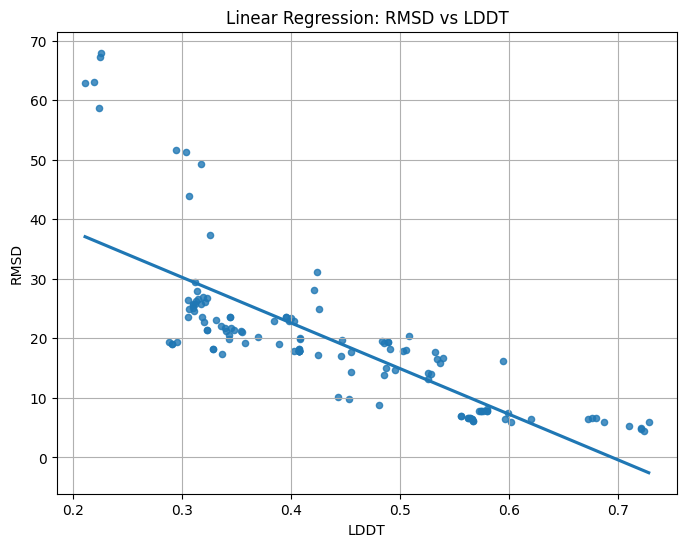

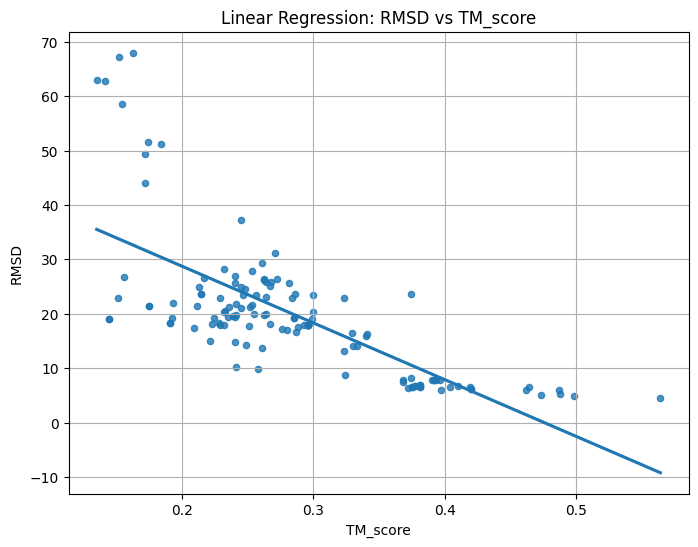

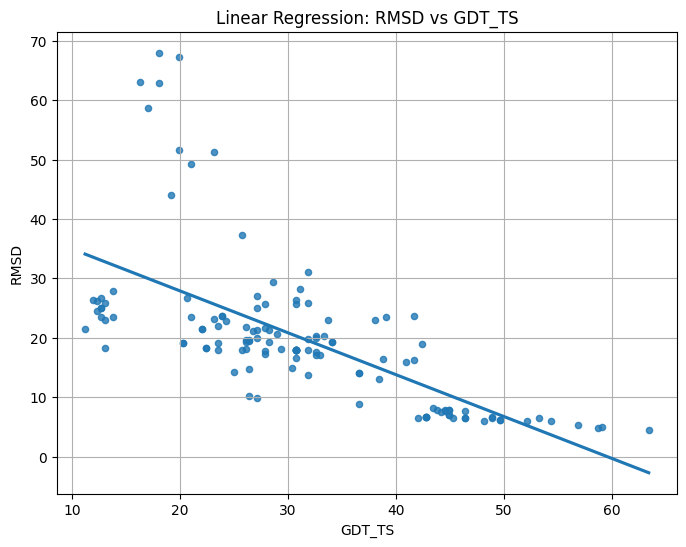

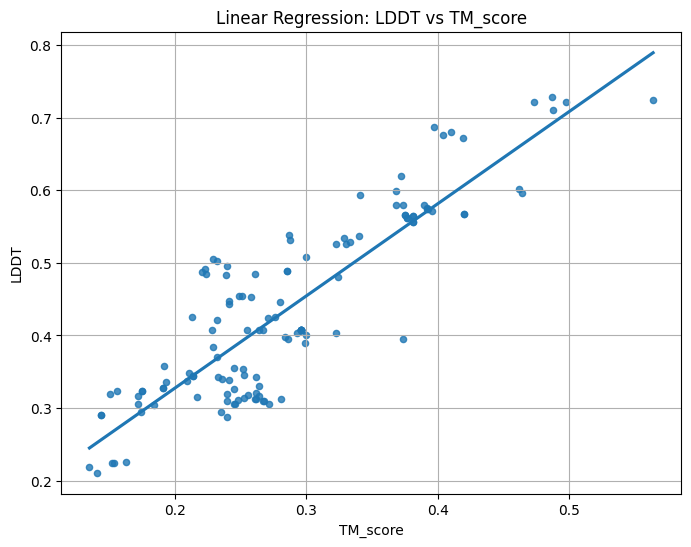

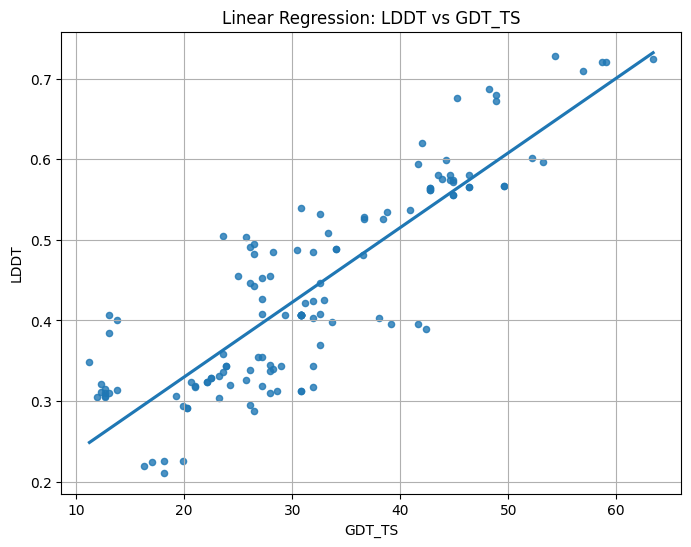

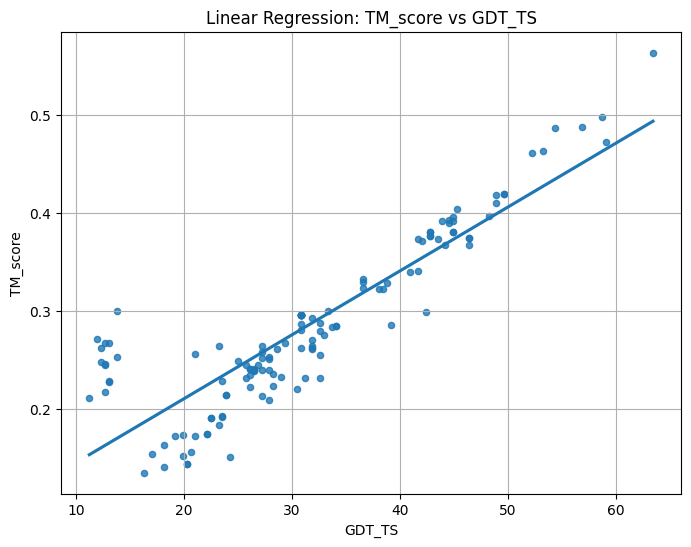

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

dependent_metrics = ['RMSD', 'LDDT', 'TM_score', 'GDT_TS']

for i in range(len(dependent_metrics)):
    for j in range(i + 1, len(dependent_metrics)):
        metric1 = dependent_metrics[i]
        metric2 = dependent_metrics[j]

        plt.figure(figsize=(8, 6))
        sns.regplot(data=df_metrics, x=metric2, y=metric1, ci=None, scatter_kws={'s': 20}) # Use regplot for scatter plot with regression line
        plt.title(f'Linear Regression: {metric1} vs {metric2}')
        plt.xlabel(metric2)
        plt.ylabel(metric1)
        plt.grid(True)
        plt.show()

### Analiza wyników

Na podstawie przeprowadzonych analiz regresji liniowej dla par zależnych metryk (RMSD, LDDT, TM_score, GDT_TS) i odpowiadających im wizualizacji (wykresy punktowe z liniami regresji), możemy zaobserwować następujące zależności:

#### RMSD vs LDDT

*   **Wyniki regresji:**
    *   Współczynnik regresji dla LDDT: około -76.68. Oznacza to, że wzrost LDDT o 1 jednostkę jest związany ze spadkiem RMSD o około 76.68 jednostek, przy założeniu liniowej zależności.
    *   R-kwadrat: około 0.586. Wskazuje, że około 58.6% zmienności w RMSD może być wyjaśnione przez liniową zależność z LDDT.
    *   P-wartość dla współczynnika LDDT jest bardzo mała (bliska 0.000), co potwierdza statystyczną istotność tej zależności liniowej.
*   **Wizualizacja:** Wykres punktowy pokazuje wyraźną ujemną liniową tendencję, gdzie punkty skupiają się wokół opadającej linii regresji.

#### RMSD vs TM_score

*   **Wyniki regresji:**
    *   Współczynnik regresji dla TM\_score: około -104.25. Wzrost TM\_score o 1 jednostkę jest związany ze spadkiem RMSD o około 104.25 jednostek.
    *   R-kwadrat: około 0.511. Około 51.1% zmienności w RMSD może być wyjaśnione przez liniową zależność z TM\_score.
    *   P-wartość dla współczynnika TM\_score jest bardzo mała (bliska 0.000), co potwierdza statystyczną istotność.
*   **Wizualizacja:** Wykres punktowy pokazuje silną ujemną liniową tendencję.

#### RMSD vs GDT_TS

*   **Wyniki regresji:**
    *   Współczynnik regresji dla GDT\_TS: około -0.7053. Wzrost GDT\_TS o 1 jednostkę jest związany ze spadkiem RMSD o około 0.7053 jednostki.
    *   R-kwadrat: około 0.427. Około 42.7% zmienności w RMSD może być wyjaśnione przez liniową zależność z GDT\_TS.
    *   P-wartość dla współczynnika GDT\_TS jest bardzo mała (bliska 0.000), co potwierdza statystyczną istotność.
*   **Wizualizacja:** Wykres punktowy pokazuje ujemną liniową tendencję, choć rozrzut punktów może być nieco większy niż w przypadku LDDT i TM\_score.

#### LDDT vs TM_score

*   **Wyniki regresji:**
    *   Współczynnik regresji dla TM\_score: około 1.2687. Wzrost TM\_score o 1 jednostkę jest związany ze wzrostem LDDT o około 1.2687 jednostki.
    *   R-kwadrat: około 0.758. Około 75.8% zmienności w LDDT może być wyjaśnione przez liniową zależność z TM\_score.
    *   P-wartość dla współczynnika TM\_score jest bardzo mała (bliska 0.000), co potwierdza statystyczną istotność.
*   **Wizualizacja:** Wykres punktowy pokazuje bardzo silną dodatnią liniową tendencję.

#### LDDT vs GDT_TS

*   **Wyniki regresji:**
    *   Współczynnik regresji dla GDT\_TS: około 0.0093. Wzrost GDT\_TS o 1 jednostkę jest związany ze wzrostem LDDT o około 0.0093 jednostki.
    *   R-kwadrat: około 0.739. Około 73.9% zmienności w LDDT może być wyjaśnione przez liniową zależność z GDT\_TS.
    *   P-wartość dla współczynnika GDT\_TS jest bardzo mała (bliska 0.000), co potwierdza statystyczną istotność.
*   **Wizualizacja:** Wykres punktowy pokazuje bardzo silną dodatnią liniową tendencję, podobną do LDDT vs TM\_score.

#### TM_score vs GDT_TS

*   **Wyniki regresji:**
    *   Współczynnik regresji dla GDT\_TS: około 0.0065. Wzrost GDT\_TS o 1 jednostkę jest związany ze wzrostem TM\_score o około 0.0065 jednostki.
    *   R-kwadrat: około 0.779. Około 77.9% zmienności w TM\_score może być wyjaśnione przez liniową zależność z GDT\_TS.
    *   P-wartość dla współczynnika GDT\_TS jest bardzo mała (bliska 0.000), co potwierdza statystyczną istotność.
*   **Wizualizacja:** Wykres punktowy pokazuje najsilniejszą dodatnią liniową tendencję spośród wszystkich par, co znajduje odzwierciedlenie w najwyższej wartości R-kwadrat.

**Ogólne wnioski:**

Analiza regresji liniowej potwierdza silne liniowe zależności między metrykami RMSD, LDDT, TM\_score i GDT\_TS, które były już widoczne w analizie korelacji. Współczynniki R-kwadrat są umiarkowane do wysokich (od ~0.43 do ~0.78), co wskazuje, że modele regresji liniowej dobrze wyjaśniają zmienność w tych parach metryk. Wizualizacje potwierdzają te zależności, pokazując, że punkty danych układają się wzdłuż linii regresji.

Metryki RMSD, LDDT, TM\_score i GDT\_TS są ze sobą ściśle powiązane w sposób liniowy, co jest zgodne z ich przeznaczeniem do oceny podobieństwa strukturalnego.

# Ocena 4.5
Analiza normalności rozkładów

## Analiza normalności rozkładów

Przeprowadzenie testów statystycznych (np. Shapiro-Wilka) i wizualizacji (np. wykresów Q-Q), aby ocenić, czy rozkład danych dla każdej z kluczowych metryk strukturalnych jest zbliżony do rozkładu normalnego.

Shapiro-Wilk Test for Normality:
RMSD: Statistics=0.802, p=0.000


<Figure size 600x400 with 0 Axes>

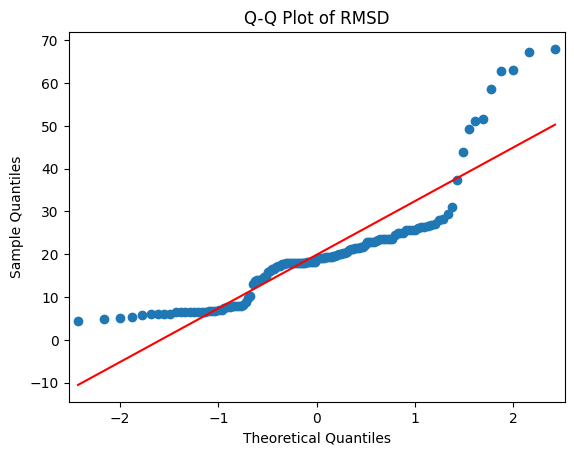

LDDT: Statistics=0.947, p=0.000


<Figure size 600x400 with 0 Axes>

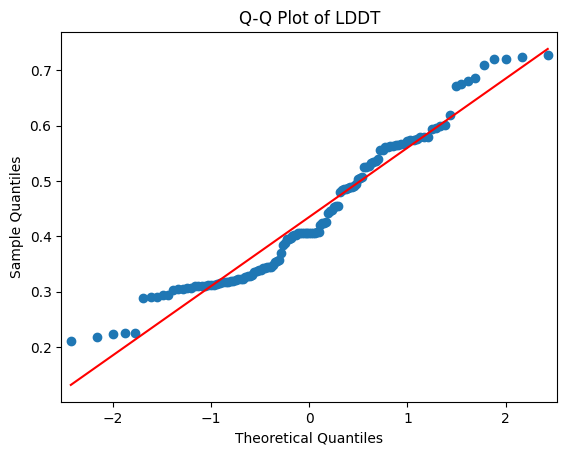

TM_score: Statistics=0.957, p=0.000


<Figure size 600x400 with 0 Axes>

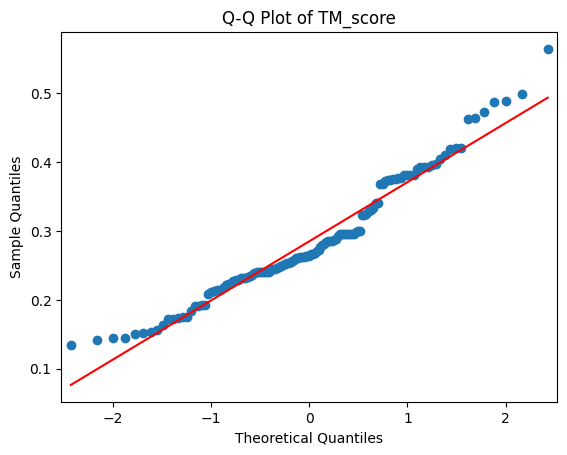

GDT_TS: Statistics=0.970, p=0.005


<Figure size 600x400 with 0 Axes>

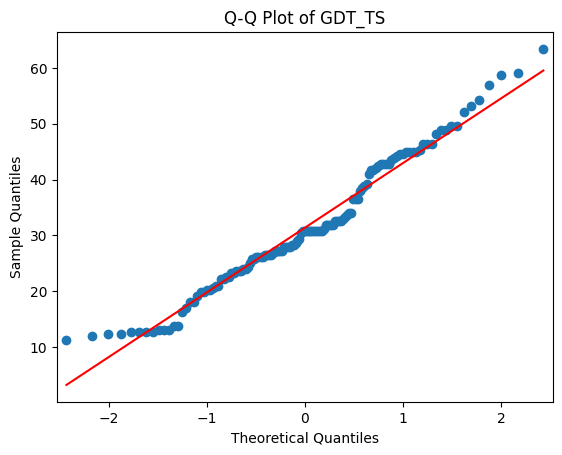

Clash: Statistics=0.663, p=0.000


<Figure size 600x400 with 0 Axes>

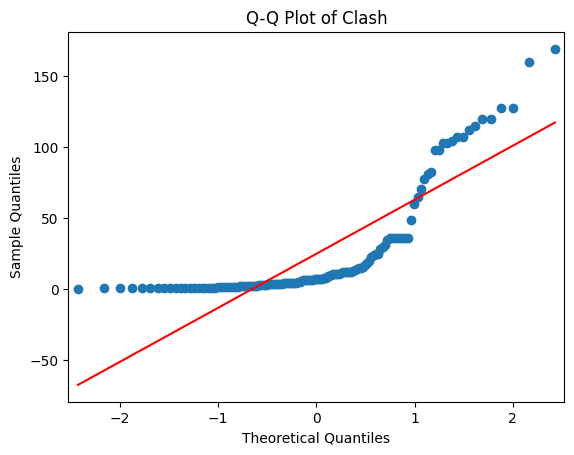

In [ ]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import statsmodels.api as sm

metrics_columns = ['RMSD', 'LDDT', 'TM_score', 'GDT_TS', 'Clash']

print("Shapiro-Wilk Test for Normality:")
for col in metrics_columns:
    # Shapiro-Wilk test
    stat, p = shapiro(df_metrics[col])
    print(f'{col}: Statistics={stat:.3f}, p={p:.3f}')

    # Q-Q Plot
    plt.figure(figsize=(6, 4))
    sm.qqplot(df_metrics[col], line='s') # 's' stands for standardized line
    plt.title(f'Q-Q Plot of {col}')
    plt.show()

### Interpretacja wyników testu Shapiro-Wilka i wykresów Q-Q (przy $\alpha = 0.05$):

$H_0$: Dane pochodzą z rozkładu normalnego.

Istotna statystycznie p-wartość (mniejsza niż $\alpha$ = 0.05) prowadzi do odrzucenia hipotezy zerowej ($H_0$).

* RMSD:
  * Test Shapiro-Wilka: p-wartość = 0.000. Jest to znacznie mniej niż 0.05. Odrzucamy hipotezę zerową o normalności rozkładu.
  * Wykres Q-Q: Punkty znacząco odbiegają od linii prostej, szczególnie na końcach. Sugeruje to rozkład, który nie jest normalny, prawdopodobnie skośny.
  * Ocena: Rozkład RMSD nie jest normalny.
* LDDT:
  * Test Shapiro-Wilka: p-wartość = 0.000. Mniej niż 0.05. Odrzucamy hipotezę zerową.
  * Wykres Q-Q: Punkty dość mocno odbiegają od linii prostej, zwłaszcza w ogonach.
  * Ocena: Rozkład LDDT nie jest normalny.
* TM_score:
  * Test Shapiro-Wilka: p-wartość = 0.000. Mniej niż 0.05. Odrzucamy hipotezę zerową.
  * Wykres Q-Q: Podobnie jak LDDT, punkty odbiegają od linii prostej.
  * Ocena: Rozkład TM_score nie jest normalny.
* GDT_TS:
  * Test Shapiro-Wilka: p-wartość = 0.005. Mniej niż 0.05. Odrzucamy hipotezę zerową.
  * Wykres Q-Q: Punkty wykazują pewne odchylenia od linii prostej, zwłaszcza na krańcach rozkładu.
  * Ocena: Rozkład GDT_TS nie jest normalny.
* Clash:
  * Test Shapiro-Wilka: p-wartość = 0.000. Mniej niż 0.05. Odrzucamy hipotezę zerową.
  * Wykres Q-Q: Punkty bardzo wyraźnie odbiegają od linii prostej, co wskazuje na silne odchylenie od normalności, prawdopodobnie spowodowane wartościami odstającymi lub silną skośnością.
  * Ocena: Rozkład Clash nie jest normalny.

#### Ogólne wnioski z analizy normalności:

Na podstawie wyników testu Shapiro-Wilka (wszystkie p-wartości znacznie poniżej 0.05) i wizualnej oceny wykresów Q-Q, możemy stwierdzić, że rozkład danych dla żadnej z analizowanych metryk (RMSD, LDDT, TM_score, GDT_TS, Clash) nie jest zbliżony do rozkładu normalnego. Mimo tego, że statistics dla niektórych metryk jest bliska 1 to nie możemy przyjąć hipotezy zerowej, ze względu na p-wartość.

## Transformacja logitowa

### Przeskalowanie gdt ts

Utworzenie nowej kolumny dla GDT_TS, dzieląc jej wartości przez 100, aby przeskalować je do zakresu (0, 1).


In [ ]:
df_metrics_transformed = df_metrics.copy()
df_metrics_transformed['GDT_TS_scaled'] = df_metrics_transformed['GDT_TS'] / 100
display(df_metrics_transformed.head())

,RMSD,LDDT,TM_score,GDT_TS,Clash,GDT_TS_scaled
0,4.52,0.724,0.564,63.41,14.93,0.6341
1,4.85,0.721,0.498,58.69,9.05,0.5869
2,5.31,0.710,0.488,56.88,11.76,0.5688
3,5.94,0.728,0.487,54.34,17.19,0.5434
4,5.02,0.721,0.473,59.06,10.40,0.5906


### Zastosowanie transformacji logitowej

Zastosowano transformację logitową ($y = \log(\frac{x}{1-x})$) do kolumn LDDT, TM_score i przeskalowanej GDT_TS. Utworzenie nowej kolumny dla przetransformowanych danych.


In [ ]:
import numpy as np

df_metrics_transformed['LDDT_logit'] = np.log(df_metrics_transformed['LDDT'] / (1 - df_metrics_transformed['LDDT']))
df_metrics_transformed['TM_score_logit'] = np.log(df_metrics_transformed['TM_score'] / (1 - df_metrics_transformed['TM_score']))
df_metrics_transformed['GDT_TS_logit'] = np.log(df_metrics_transformed['GDT_TS_scaled'] / (1 - df_metrics_transformed['GDT_TS_scaled']))

display(df_metrics_transformed.head())

,RMSD,LDDT,TM_score,GDT_TS,Clash,GDT_TS_scaled,LDDT_logit,TM_score_logit,GDT_TS_logit
0,4.52,0.724,0.564,63.41,14.93,0.6341,0.964391,0.257412,0.549847
1,4.85,0.721,0.498,58.69,9.05,0.5869,0.949427,-0.008000,0.351165
2,5.31,0.710,0.488,56.88,11.76,0.5688,0.895384,-0.048009,0.276957
3,5.94,0.728,0.487,54.34,17.19,0.5434,0.984499,-0.052012,0.174038
4,5.02,0.721,0.473,59.06,10.40,0.5906,0.949427,-0.108105,0.366446


### Analiza normalności po transformacji

Dla każdej z przetransformowanych kolumn (LDDT, TM_score, GDT_TS), powtórzono analizę normalności:
*   Wygenerowano wykres Kwantyl-Kwantyl (Q-Q plot).
*   Wykonano test Shapiro-Wilka.


Shapiro-Wilk Test and Q-Q Plots for Logit-Transformed Metrics:

Analyzing: LDDT_logit
Shapiro-Wilk Test: Statistics=0.957, p=0.000


<Figure size 600x400 with 0 Axes>

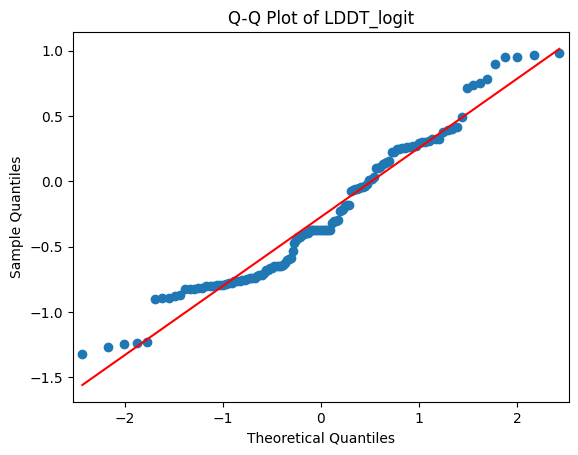


Analyzing: TM_score_logit
Shapiro-Wilk Test: Statistics=0.981, p=0.066


<Figure size 600x400 with 0 Axes>

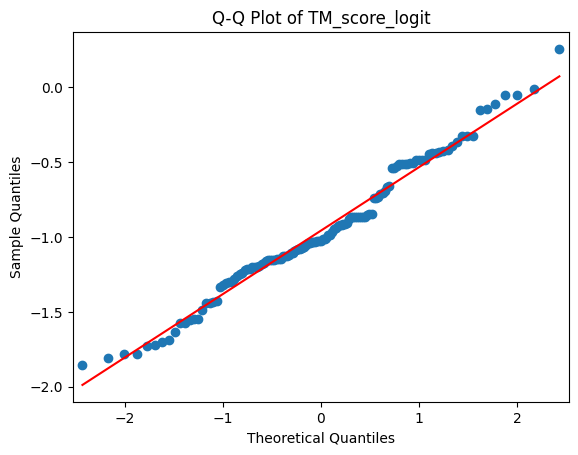


Analyzing: GDT_TS_logit
Shapiro-Wilk Test: Statistics=0.979, p=0.041


<Figure size 600x400 with 0 Axes>

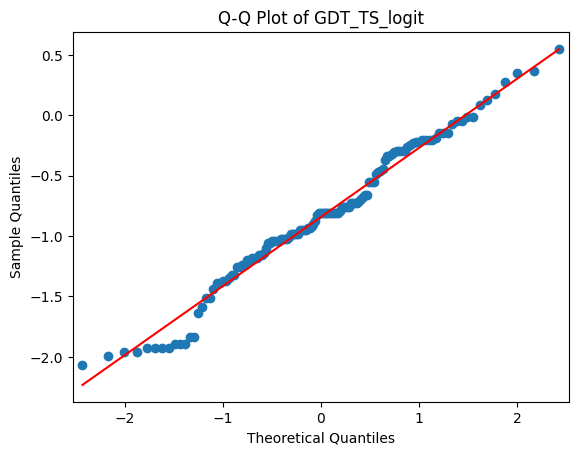

In [ ]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import statsmodels.api as sm

logit_transformed_columns = ['LDDT_logit', 'TM_score_logit', 'GDT_TS_logit']

print("Shapiro-Wilk Test and Q-Q Plots for Logit-Transformed Metrics:")
for col in logit_transformed_columns:
    print(f'\nAnalyzing: {col}')

    # Shapiro-Wilk test
    stat, p = shapiro(df_metrics_transformed[col])
    print(f'Shapiro-Wilk Test: Statistics={stat:.3f}, p={p:.3f}')

    # Q-Q Plot
    plt.figure(figsize=(6, 4))
    sm.qqplot(df_metrics_transformed[col], line='s') # 's' stands for standardized line
    plt.title(f'Q-Q Plot of {col}')
    plt.show()

### Interpretacja analizy normalności po transformacji logitowej

Przeprowadzona analiza normalności rozkładów metryk LDDT, TM_score i GDT_TS po zastosowaniu transformacji logitowej pozwala na porównanie wyników z analizą przeprowadzoną na oryginalnych danych i ocenę wpływu tej transformacji.

**Porównanie wyników przed i po transformacji logitowej:**

Przed transformacją, test Shapiro-Wilka wykazał statystycznie istotne odchylenia od normalności dla wszystkich trzech metryk (p-wartości znacznie poniżej 0.05). Wykresy Q-Q dla oryginalnych danych pokazywały wyraźne odchylenia punktów od teoretycznej linii prostej, co wizualnie potwierdzało brak normalnego rozkładu, szczególnie w ogonach rozkładu.

Po zastosowaniu transformacji logitowej:

*   **LDDT\_logit:**
    *   **Wykres Q-Q:** Wizualna ocena wykresu Q-Q dla `LDDT_logit` wskazuje, że transformacja **nie spowodowała znaczącego przybliżenia punktów do linii prostej**. Odchylenia, zwłaszcza na krańcach rozkładu, są nadal wyraźne i podobne do tych obserwowanych przed transformacją.
    *   **Test Shapiro-Wilka:** P-wartość testu Shapiro-Wilka dla `LDDT_logit` wynosi 0.000. Jest to wartość znacznie poniżej progu istotności 0.05.
    *   **Wpływ transformacji:** Test statystyczny potwierdza wizualną ocenę – transformacja logitowa **nie poprawiła normalności rozkładu LDDT**. Rozkład `LDDT_logit` nadal statystycznie istotnie odbiega od rozkładu normalnego.

*   **TM\_score\_logit:**
    *   **Wykres Q-Q:** Na wykresie Q-Q dla `TM_score_logit` widać **wyraźne przybliżenie punktów do teoretycznej linii prostej** w porównaniu do oryginalnego `TM_score`. Punkty układają się znacznie bliżej linii, sugerując lepsze dopasowanie do rozkładu normalnego.
    *   **Test Shapiro-Wilka:** P-wartość testu dla `TM_score_logit` wynosi 0.066. Jest to wartość **powyżej progu istotności 0.05**.
    *   **Wpływ transformacji:** Zarówno wizualna ocena wykresu Q-Q, jak i wynik testu Shapiro-Wilka wskazują, że transformacja logitowa **znacząco poprawiła normalność rozkładu TM_score**. Na poziomie istotności 0.05, nie mamy statystycznych podstaw, aby odrzucić hipotezę o normalności rozkładu `TM_score_logit`.

*   **GDT\_TS\_logit:**
    *   **Wykres Q-Q:** Wykres Q-Q dla `GDT_TS_logit` pokazuje **pewne przybliżenie punktów do linii prostej** w porównaniu do oryginalnego `GDT_TS`, ale odchylenia, szczególnie w ogonach, są nadal widoczne. Dopasowanie jest lepsze niż dla `LDDT_logit`, ale gorsze niż dla `TM_score_logit`.
    *   **Test Shapiro-Wilka:** P-wartość testu dla `GDT_TS_logit` wynosi 0.041. Jest to wartość **poniżej progu istotności 0.05**, choć blisko niego.
    *   **Wpływ transformacji:** Transformacja logitowa **częściowo poprawiła normalność rozkładu GDT_TS** (p-wartość wzrosła z 0.005 do 0.041), co widać na wykresie Q-Q. Jednakże, na poziomie istotności 0.05, rozkład `GDT_TS_logit` nadal statystycznie istotnie odbiega od normalnego.

**Podsumowanie wpływu transformacji:**

Transformacja logitowa okazała się **najskuteczniejsza w przybliżeniu rozkładu `TM_score` do normalnego**. Dla `GDT_TS` przyniosła pewną poprawę, ale niewystarczającą do uznania rozkładu za normalny na poziomie istotności 0.05. Dla `LDDT` transformacja nie przyniosła widocznej poprawy w normalności rozkładu.

# Ocena 5
Kompleksowa analiza rankingów modeli

## Standardowy Z-score

Obliczenie standardowego Z-score dla każdej z kluczowych metryk strukturalnych (RMSD, Clash, LDDT, TM_score, GDT_TS) według wzoru $Z_i = (x_i - \mu) / \sigma$.

In [ ]:
import pandas as pd

# Calculate Z-scores for each metric
metrics_columns = ['RMSD', 'LDDT', 'TM_score', 'GDT_TS', 'Clash']

# Create a new DataFrame for Z-scores with the same index as df_metrics
df_zscores = pd.DataFrame(index=df_metrics.index)

for col in metrics_columns:
    mean = df_metrics[col].mean()
    std = df_metrics[col].std()
    # Avoid division by zero if standard deviation is 0
    if std != 0:
        df_zscores[f'{col}_Zscore'] = (df_metrics[col] - mean) / std
    else:
        df_zscores[f'{col}_Zscore'] = 0

print("DataFrame with Z-scores:")
display(df_zscores.head())
display(df_zscores.tail())

DataFrame with Z-scores:


,RMSD_Zscore,LDDT_Zscore,TM_score_Zscore,GDT_TS_Zscore,Clash_Zscore
0,-1.222515,2.301516,3.240629,2.751831,-0.258665
1,-1.196252,2.277607,2.474301,2.346409,-0.412512
2,-1.159642,2.189939,2.358191,2.190940,-0.341606
3,-1.109502,2.333395,2.346580,1.972768,-0.199534
4,-1.182722,2.277607,2.184025,2.378190,-0.377190


,RMSD_Zscore,LDDT_Zscore,TM_score_Zscore,GDT_TS_Zscore,Clash_Zscore
126,0.233932,-0.918295,-1.554725,-0.609222,-0.590167
127,-0.066908,-1.149420,-1.636002,-0.951941,-0.329832
128,-0.066908,-1.149420,-1.636002,-0.951941,-0.329832
129,3.417424,-1.787006,-1.670836,-1.139191,-0.528158
130,3.431749,-1.723247,-1.740502,-1.294660,-0.624966


## Robust Z-score

Obliczenie mediany (M) wartości metryki.

Obliczenie bezwzględnego odchylenia od mediany: $|x_i - M|$.

Obliczenie MAD (median absolute deviation) - mediany tych odchyleń.

Obliczenie robust Z-score $RZ_i = 0.6745 \cdot (x_i - M) / MAD$.

**Uwaga:** Współczynnik 0.6745 umożliwia interpretację wartości Robust Z-score w podobny sposób do standardowego Z-score. Oznacza to, że 68% wartości mieści się w przedziale $[-1, 1]$, 95% w przedziale $[-2, 2]$, a 99.7% w przedziale $[-3, 3]$.

In [ ]:
import pandas as pd
import numpy as np

metrics_columns = ['RMSD', 'LDDT', 'TM_score', 'GDT_TS', 'Clash']

# Create a new DataFrame for Robust Z-scores with the same index as df_metrics
df_robust_zscores = pd.DataFrame(index=df_metrics.index)

for col in metrics_columns:
    # Calculate Median (M)
    median = df_metrics[col].median()

    # Calculate absolute deviations from the median
    absolute_deviations = np.abs(df_metrics[col] - median)

    # Calculate MAD (Median Absolute Deviation)
    mad = absolute_deviations.median()

    # Calculate Robust Z-score
    # Avoid division by zero if MAD is 0
    if mad != 0:
        df_robust_zscores[f'{col}_RobustZscore'] = 0.6745 * (df_metrics[col] - median) / mad
    else:
        # Handle cases where MAD is 0 (all values are the same) - Robust Z-score is 0
        df_robust_zscores[f'{col}_RobustZscore'] = 0

print("DataFrame with Robust Z-scores:")
display(df_robust_zscores.head())
display(df_robust_zscores.tail())

DataFrame with Robust Z-scores:


,RMSD_RobustZscore,LDDT_RobustZscore,TM_score_RobustZscore,GDT_TS_RobustZscore,Clash_RobustZscore
0,-2.084032,2.375739,4.935366,2.890334,0.939688
1,-2.036471,2.353256,3.849585,2.471985,0.261729
2,-1.970174,2.270817,3.685073,2.311558,0.574190
3,-1.879376,2.405717,3.668622,2.086430,1.200264
4,-2.011970,2.353256,3.438305,2.504779,0.417383


,RMSD_RobustZscore,LDDT_RobustZscore,TM_score_RobustZscore,GDT_TS_RobustZscore,Clash_RobustZscore
126,0.553436,-0.652017,-1.858988,-0.577890,-0.521152
127,0.008647,-0.869356,-1.974146,-0.931537,0.626074
128,0.008647,-0.869356,-1.974146,-0.931537,0.626074
129,6.318393,-1.468911,-2.023500,-1.124758,-0.247893
130,6.344335,-1.408956,-2.122207,-1.285184,-0.674500


## Identyfikacja Obserwacji Odstających (Outlierów)

### Identyfikacja outlierów na podstawie standardowego Z-score

Dla każdej metryki zostały zidentyfikowane wiersze, gdzie wartość bezwzględna standardowego Z-score jest większa od 3.


In [ ]:
# Create an empty dictionary to store outliers
standard_zscore_outliers = {}

# Iterate through the Z-score columns
for col in df_zscores.columns:
    # Identify indices where the absolute Z-score is greater than 3
    outlier_indices = df_zscores[df_zscores[col].abs() > 3].index.tolist()

    # Get the original metric name by removing '_Zscore'
    metric_name = col.replace('_Zscore', '')

    # Store the outlier indices in the dictionary
    standard_zscore_outliers[metric_name] = outlier_indices

# Display the dictionary of standard Z-score outliers
print("Standard Z-score Outliers (absolute Z-score > 3):")
display(standard_zscore_outliers)

Standard Z-score Outliers (absolute Z-score > 3):


{'RMSD': [122, 124, 125, 129, 130],
 'LDDT': [],
 'TM_score': [0],
 'GDT_TS': [],
 'Clash': [40, 64]}

### Identyfikacja outlierów na podstawie Robust Z-score

Dla każdej metryki zostały zidentyfikowane wiersze, gdzie wartość bezwzględna Robust Z-score jest większa od 3.



In [ ]:
# Create an empty dictionary to store robust Z-score outliers
robust_zscore_outliers = {}

# Iterate through the Robust Z-score columns
for col in df_robust_zscores.columns:
    # Identify indices where the absolute Robust Z-score is greater than 3
    outlier_indices = df_robust_zscores[df_robust_zscores[col].abs() > 3].index.tolist()

    # Get the original metric name by removing '_RobustZscore'
    metric_name = col.replace('_RobustZscore', '')

    # Store the outlier indices in the dictionary
    robust_zscore_outliers[metric_name] = outlier_indices

# Display the dictionary of robust Z-score outliers
print("Robust Z-score Outliers (absolute Robust Z-score > 3):")
display(robust_zscore_outliers)

Robust Z-score Outliers (absolute Robust Z-score > 3):


{'RMSD': [116, 119, 120, 121, 122, 124, 125, 129, 130],
 'LDDT': [],
 'TM_score': [0, 1, 2, 3, 4, 5, 6],
 'GDT_TS': [],
 'Clash': [7,
  8,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  31,
  40,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  51,
  64,
  85,
  86,
  90,
  92,
  95,
  116,
  119,
  120,
  121]}

### Porównanie
Porównanie list outlierów zidentyfikowanych obiema metodami.



In [ ]:
# Compare the findings
print("\nComparison of Standard and Robust Z-score Outliers:")

for metric in metrics_columns:
    standard_outliers = standard_zscore_outliers.get(metric, [])
    robust_outliers = robust_zscore_outliers.get(metric, [])

    print(f"\nMetric: {metric}")
    print(f"Standard Z-score outliers ({len(standard_outliers)}): {standard_outliers}")
    print(f"Robust Z-score outliers ({len(robust_outliers)}): {robust_outliers}")

    common_outliers = set(standard_outliers).intersection(set(robust_outliers))
    standard_only = set(standard_outliers) - set(robust_outliers)
    robust_only = set(robust_outliers) - set(standard_outliers)

    print(f"Common outliers ({len(common_outliers)}): {sorted(list(common_outliers))}")
    print(f"Outliers identified only by Standard Z-score ({len(standard_only)}): {sorted(list(standard_only))}")
    print(f"Outliers identified only by Robust Z-score ({len(robust_only)}): {sorted(list(robust_only))}")


Comparison of Standard and Robust Z-score Outliers:

Metric: RMSD
Standard Z-score outliers (5): [122, 124, 125, 129, 130]
Robust Z-score outliers (9): [116, 119, 120, 121, 122, 124, 125, 129, 130]
Common outliers (5): [122, 124, 125, 129, 130]
Outliers identified only by Standard Z-score (0): []
Outliers identified only by Robust Z-score (4): [116, 119, 120, 121]

Metric: LDDT
Standard Z-score outliers (0): []
Robust Z-score outliers (0): []
Common outliers (0): []
Outliers identified only by Standard Z-score (0): []
Outliers identified only by Robust Z-score (0): []

Metric: TM_score
Standard Z-score outliers (1): [0]
Robust Z-score outliers (7): [0, 1, 2, 3, 4, 5, 6]
Common outliers (1): [0]
Outliers identified only by Standard Z-score (0): []
Outliers identified only by Robust Z-score (6): [1, 2, 3, 4, 5, 6]

Metric: GDT_TS
Standard Z-score outliers (0): []
Robust Z-score outliers (0): []
Common outliers (0): []
Outliers identified only by Standard Z-score (0): []
Outliers identif

### Interpretacja:

* Standardowa metoda Z-score zidentyfikowała 5 wartości odstających dla „RMSD”, 1 dla „TM_score” i 2 dla „Clash”. Nie znalazła wartości odstających dla „LDDT” i „GDT_TS”.

* Metoda Robust Z-score zidentyfikowała znacznie więcej wartości odstających dla „RMSD” (9), „TM_score” (7) i „Clash” (31) w porównaniu do standardowej metody Z-score. Podobnie jak metoda standardowa, nie znalazła wartości odstających dla „LDDT” i „GDT_TS”.

* Znacząca różnica w liczbie wartości odstających zidentyfikowanych przez obie metody, szczególnie dla „Clash”, sugeruje, że metryki te prawdopodobnie nie mają rozkładu normalnego lub zawierają wartości ekstremalne.

## Wyznaczenie Sumarycznego Z-score i Robust Z-score

In [ ]:
import pandas as pd

# Create copies of the Z-score and Robust Z-score DataFrames to avoid modifying the originals
df_zscores_modified = df_zscores.copy()
df_robust_zscores_modified = df_robust_zscores.copy()

# Reverse the sign for RMSD and Clash Z-scores
df_zscores_modified['RMSD_Zscore'] = df_zscores_modified['RMSD_Zscore'] * -1
df_zscores_modified['Clash_Zscore'] = df_zscores_modified['Clash_Zscore'] * -1

# Reverse the sign for RMSD and Clash Robust Z-scores
df_robust_zscores_modified['RMSD_RobustZscore'] = df_robust_zscores_modified['RMSD_RobustZscore'] * -1
df_robust_zscores_modified['Clash_RobustZscore'] = df_robust_zscores_modified['Clash_RobustZscore'] * -1

# Calculate the sum of all modified Z-scores for each model (row-wise sum)
df_rna['Sum_Zscore'] = df_zscores_modified.sum(axis=1)

# Calculate the sum of all modified Robust Z-scores for each model (row-wise sum)
df_rna['Sum_RobustZscore'] = df_robust_zscores_modified.sum(axis=1)

print("DataFrame df_rna with Sum_Zscore and Sum_RobustZscore:")
display(df_rna[['Model', 'Sum_Zscore', 'Sum_RobustZscore']].head())
display(df_rna[['Model', 'Sum_Zscore', 'Sum_RobustZscore']].tail())

DataFrame df_rna with Sum_Zscore and Sum_RobustZscore:


,Model,Sum_Zscore,Sum_RobustZscore
0,R1107TS232_1,9.775156,11.345783
1,R1107TS232_2,8.707079,10.449568
2,R1107TS232_4,8.240317,9.663433
3,R1107TS232_3,7.961778,8.839880
4,R1107TS232_5,8.399733,9.890927


,Model,Sum_Zscore,Sum_RobustZscore
126,R1107TS035_4,-2.726006,-3.121178
127,R1107TS245_5,-3.340622,-4.409760
128,R1107TS385_5,-3.340622,-4.409760
129,R1107TS091_2,-7.486298,-10.687669
130,R1107TS091_3,-7.565192,-10.486182


## Porównanie Rankingów

Utworzenie rankingu modeli na podstawie sumarycznego Z-score i Robust Z-score, porównanie obu rankingów, używając współczynnika korelacji Spearmana i analizując różnice w top 10 modeli.

### Ranking według sumarycznego Z-score

Posortowanie DataFrame w oparciu o kolumnę `Sum_Zscore` w malejącej kolejności.


In [ ]:
df_ranked_by_zscore = df_rna.sort_values(by='Sum_Zscore', ascending=False)
display(df_ranked_by_zscore[['Model', 'Sum_Zscore', 'Sum_RobustZscore']].head())

,Model,Sum_Zscore,Sum_RobustZscore
0,R1107TS232_1,9.775156,11.345783
1,R1107TS232_2,8.707079,10.449568
4,R1107TS232_5,8.399733,9.890927
2,R1107TS232_4,8.240317,9.663433
3,R1107TS232_3,7.961778,8.839880


### Ranking według sumarycznego robust z-score

Posortowanie DataFrame w oparciu o kolumnę `Sum_RobustZscore` w malejącej kolejności.


In [ ]:
df_ranked_by_robust_zscore = df_rna.sort_values(by='Sum_RobustZscore', ascending=False)
display(df_ranked_by_robust_zscore[['Model', 'Sum_Zscore', 'Sum_RobustZscore']].head())

,Model,Sum_Zscore,Sum_RobustZscore
0,R1107TS232_1,9.775156,11.345783
1,R1107TS232_2,8.707079,10.449568
4,R1107TS232_5,8.399733,9.890927
2,R1107TS232_4,8.240317,9.663433
3,R1107TS232_3,7.961778,8.839880


### Wyświetlenie top 10

Wyświetlenie top 10 modeli z każdego rankingu.


In [ ]:
print("Top 10 models ranked by Standard Z-score:")
display(df_ranked_by_zscore[['Model', 'Sum_Zscore', 'Sum_RobustZscore']].head(10))

print("\nTop 10 models ranked by Robust Z-score:")
display(df_ranked_by_robust_zscore[['Model', 'Sum_Zscore', 'Sum_RobustZscore']].head(10))

Top 10 models ranked by Standard Z-score:


,Model,Sum_Zscore,Sum_RobustZscore
0,R1107TS232_1,9.775156,11.345783
1,R1107TS232_2,8.707079,10.449568
4,R1107TS232_5,8.399733,9.890927
2,R1107TS232_4,8.240317,9.663433
3,R1107TS232_3,7.961778,8.839880
9,R1107TS287_2,6.642750,8.620625
10,R1107TS287_1,6.525903,8.240525
5,R1107TS416_5,6.445445,7.033785
6,R1107TS416_1,6.293337,6.461235
11,R1107TS287_4,6.183955,8.072893



Top 10 models ranked by Robust Z-score:


,Model,Sum_Zscore,Sum_RobustZscore
0,R1107TS232_1,9.775156,11.345783
1,R1107TS232_2,8.707079,10.449568
4,R1107TS232_5,8.399733,9.890927
2,R1107TS232_4,8.240317,9.663433
3,R1107TS232_3,7.961778,8.839880
9,R1107TS287_2,6.642750,8.620625
10,R1107TS287_1,6.525903,8.240525
11,R1107TS287_4,6.183955,8.072893
5,R1107TS416_5,6.445445,7.033785
15,R1107TS125_2,5.112272,6.949426


### Korelacja Spearmana

Obliczenie współczynnik korelacji Spearmana między kolumnami `Sum_Zscore` i `Sum_RobustZscore`.


In [ ]:
spearman_corr = df_rna['Sum_Zscore'].corr(df_rna['Sum_RobustZscore'], method='spearman')
print(f"Spearman correlation between Sum_Zscore and Sum_RobustZscore: {spearman_corr:.3f}")

Spearman correlation between Sum_Zscore and Sum_RobustZscore: 0.758


### Porównanie Rankingów Sumarycznego Z-score i Robust Z-score

**Współczynnik korelacji Spearmana:**

Obliczony współczynnik korelacji Spearmana między kolumnami `Sum_Zscore` a `Sum_RobustZscore` wynosi **0.758**.

*   Współczynnik ten wskazuje na **silną dodatnią monotoniczną korelację** między dwoma rankingami. Oznacza to, że modele wysoko ocenione w rankingu standardowego Z-score mają również tendencję do bycia wysoko ocenionymi w rankingu Robust Z-score, i odwrotnie. Ogólna kolejność modeli w obu rankingach jest podobna.

**Analiza Różnic w Top 10:**

*   **Modele w Top 10 Standardowego Z-score:**
    ```
    Model	Sum_Zscore	Sum_RobustZscore
    0	R1107TS232_1	9.775156	11.345783
    1	R1107TS232_2	8.707079	10.449568
    4	R1107TS232_5	8.399733	9.890927
    2	R1107TS232_4	8.240317	9.663433
    3	R1107TS232_3	7.961778	8.839880
    9	R1107TS287_2	6.642750	8.620625
    10	R1107TS287_1	6.525903	8.240525
    5	R1107TS416_5	6.445445	7.033785
    6	R1107TS416_1	6.293337	6.461235
    11	R1107TS287_4	6.183955	8.072893
    ```


*   **Modele w Top 10 Robust Z-score:**
    ```
    Model	Sum_Zscore	Sum_RobustZscore
    0	R1107TS232_1	9.775156	11.345783
    1	R1107TS232_2	8.707079	10.449568
    4	R1107TS232_5	8.399733	9.890927
    2	R1107TS232_4	8.240317	9.663433
    3	R1107TS232_3	7.961778	8.839880
    9	R1107TS287_2	6.642750	8.620625
    10	R1107TS287_1	6.525903	8.240525
    11	R1107TS287_4	6.183955	8.072893
    5	R1107TS416_5	6.445445	7.033785
    15	R1107TS125_2	5.112272	6.949426
    ```

**Obserwacje i różnice:**

*   **Duże pokrycie:** Top 7 modeli w obu rankingach jest identyczne.
*   **Różnice na pozycjach 8, 9 i 10:**
    *   W rankingu standardowego Z-score na 8. miejscu jest model `R1107TS416_5`, który w Robust Z-score jest na miejscu 9.
    *   W rankingu standardowego Z-score na 10. miejscu jest model `R1107TS287_4`, który w Robust Z-score jest na miejscu 8.

*   **Modele obecne tylko w jednym Top 10:**
    *   Model `R1107TS416_1` (na 9. miejscu w rankingu standardowego Z-score) nie znajduje się w top 10 rankingu Robust Z-score.
    *   Model `R1107TS125_2` (na 10. miejscu w rankingu Robust Z-score) nie znajduje się w top 10 rankingu standardowego Z-score.

**Wnioski:**

Silna korelacja Spearmana (0.758) potwierdza, że oba rankingi są w dużej mierze zgodne, szczególnie na wyższych pozycjach. Top 8 modeli jest identyczne, co sugeruje, że dla tych najlepiej ocenianych modeli obie metody oceny (bazujące na standardowym i Robust Z-score) dają bardzo podobne wyniki.

Różnice pojawiają się na niższych pozycjach w top 10 (miejsca 8, 9 i 10), co może sugerować, że modele te mają cechy (np. wartości odstające w jednej z metryk), które są różnie traktowane przez standardowe Z-score (bardziej wrażliwe na outliery) i Robust Z-score (mniej wrażliwe na outliery).

Mimo niewielkich różnic w top 10, ogólna struktura obu rankingów jest bardzo podobna, co potwierdza wysoką korelację Spearmana. Wybór między rankingiem opartym na standardowym Z-score a Robust Z-score może zależeć od tego, czy chcemy, aby ocena modelu była bardziej czy mniej wrażliwa na wartości odstające w poszczególnych metrykach.

## Analiza na Poziomie Grup

In [ ]:
# Calculate the average Sum_Zscore and Sum_RobustZscore for each group
group_analysis = df_rna.groupby('Group name')[['Sum_Zscore', 'Sum_RobustZscore']].mean()

print("Average Sum_Zscore and Sum_RobustZscore per group:")
display(group_analysis)

Average Sum_Zscore and Sum_RobustZscore per group:


,Sum_Zscore,Sum_RobustZscore
Group name,,
AIchemy_RNA,4.403305,4.520507
AIchemy_RNA2,8.616813,10.037918
Chen,5.072939,6.557988
CoMMiT-human,2.204089,-5.741864
CoMMiT-server,2.204089,-5.741864
Coqualia,-1.872480,-2.000839
FoldEver,-2.370536,-2.803566
FoldEver-Hybrid,-2.296095,-2.747881
GWxraylab,0.906566,1.643425


### Ranking Grup według Sumarycznego Z-score i Sumarycznego Rebust Z-score

Posortowanie DataFrame w oparciu o kolumnę `Sum_Zscore` lub `Sum_RobustZscore` w malejącej kolejności.

In [ ]:
#Average Sum_Zscore per group
group_ranked_by_zscore = group_analysis.sort_values(by='Sum_Zscore', ascending=False)
print("Average Sum_Zscore per group ranking:")
display(group_ranked_by_zscore[['Sum_Zscore']])

#Average Sum_RobustZscore per group
group_ranked_by_robust_zscore = group_analysis.sort_values(by='Sum_RobustZscore', ascending=False)
print("Average Sum_RobustZscore per group ranking:")
display(group_ranked_by_robust_zscore[['Sum_RobustZscore']])

Average Sum_Zscore per group ranking:


,Sum_Zscore
Group name,
AIchemy_RNA2,8.616813
Chen,5.072939
UltraFold,4.945065
AIchemy_RNA,4.403305
RNApolis,2.837476
CoMMiT-human,2.204089
CoMMiT-server,2.204089
UltraFold_Server,0.984049
GWxraylab,0.906566


Average Sum_RobustZscore per group ranking:


,Sum_RobustZscore
Group name,
AIchemy_RNA2,10.037918
Chen,6.557988
UltraFold,6.485739
AIchemy_RNA,4.520507
RNApolis,4.044538
GWxraylab,1.643425
Kiharalab,0.522907
UltraFold_Server,-0.129976
LCBio,-0.422409


### Porównanie Rankingów Grup

Porównanie rankingów grup opartych na średnim sumarycznym Z-score i średnim sumarycznym Robust Z-score:

* **Podobieństwa w rankingach:**
    * Grupy **AIchemy_RNA2**, **Chen**, **UltraFold**, **AIchemy_RNA**, i **RNApolis**  zajmują czołowe pozycje w obu rankingach, co sugeruje ich wysoką ogólną wydajność niezależnie od metody standaryzacji.
    * Grupy o najniższych średnich wynikach, takie jak **UNRES**, **Kiharalab_Server**, i **rDP**, również pozostają nisko w obu rankingach.

* **Różnice w rankingach:**
    * Widoczne są pewne przetasowania w środkowej części rankingów. Na przykład, grupa **GWxraylab** ma wyższą pozycję w rankingu Robust Z-score (7. miejsce) w porównaniu do rankingu standardowego Z-score (9. miejsce).
    * Grupy **CoMMiT-human** i **CoMMiT-server** mają znacznie niższe pozycje w rankingu Robust Z-score (24. i 25. miejsce) w porównaniu do rankingu standardowego Z-score (6. i 7. miejsce). Ta duża różnica sugeruje, że te grupy mogą mieć modele z wartościami odstającymi (szczególnie w metrykach, gdzie Robust Z-score zidentyfikował ich więcej, np. Clash), które znacząco wpływają na standardowy Z-score, ale są mniej wpływowe w przypadku Robust Z-score.
    * Podobnie, grupa **GeneSilico** spada znacząco w rankingu Robust Z-score (26. miejsce) w porównaniu do standardowego Z-score (10. miejsce), co może również wskazywać na wpływ wartości odstających.

* **Interpretacja różnic:**
    * Różnice w rankingach, szczególnie te znaczące spadki pozycji niektórych grup w rankingu Robust Z-score, prawdopodobnie wynikają z większej wrażliwości standardowego Z-score na wartości odstające. Robust Z-score, używając mediany i MAD, jest mniej podatny na wpływ ekstremalnych wartości, co może dawać bardziej stabilną i odporną na outliery ocenę grupy.

**Wnioski końcowe:**

Chociaż oba rankingi wykazują ogólną zgodność, zwłaszcza w przypadku najlepszych i najgorszych grup, ranking oparty na Robust Z-score może być bardziej miarodajny w obecności wartości odstających w danych. Najlepsze grupy (AIchemy_RNA2, Chen, UltraFold) wykazują spójnie wysoką wydajność niezależnie od zastosowanej metody standaryzacji.